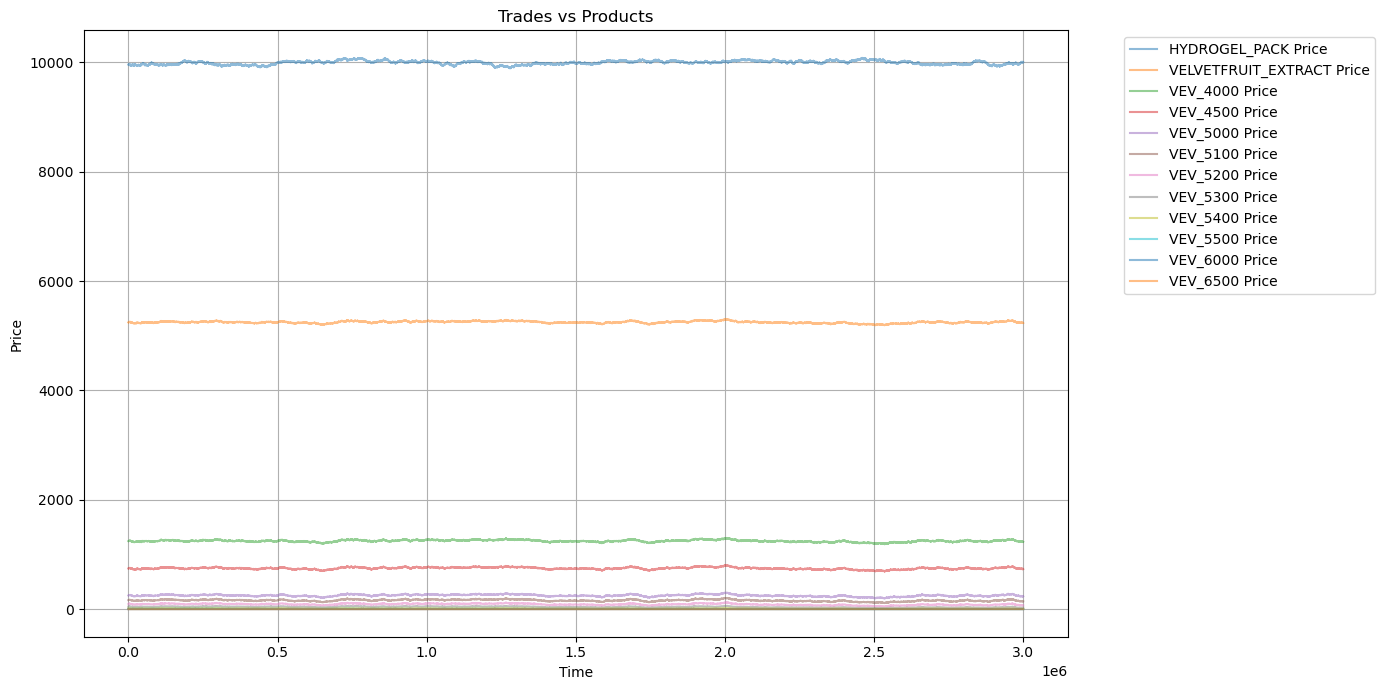

In [1]:
import pandas as pd
import os
import glob
import json
import io

import matplotlib.pyplot as plt

# Find the most recent log file in the backtests folder
log_files = glob.glob('backtests/*.log')
if not log_files:
    print("No log files found in backtests/ directory.")
else:
    latest_log = max(log_files, key=os.path.getctime)
    
    # Parse the log file to extract the activitiesLog (which contains the CSV data)
    activities_csv = ""
    with open(latest_log, 'r', encoding='utf-8') as f:
        content = f.read()
        try:
            # The backtester log often contains a single JSON object.
            log_data = json.loads(content)
            activities_csv = log_data.get('activitiesLog', '')
        except json.JSONDecodeError:
            # If it's not a single valid JSON, try finding the first parsable JSON line
            for line in content.split('\n'):
                if line.startswith('{'):
                    try:
                        log_data = json.loads(line)
                        if 'activitiesLog' in log_data:
                            activities_csv = log_data['activitiesLog']
                            break
                    except json.JSONDecodeError:
                        continue

    if not activities_csv:
        print("Could not extract activitiesLog from the log file.")
    else:
        # Load the extracted CSV string into a DataFrame
        df = pd.read_csv(io.StringIO(activities_csv), sep=';')

        # Set up the plot
        plt.figure(figsize=(14, 7))
        
        # Get unique products
        products = df['product'].unique()
        
        for prod in products:
            prod_data = df[df['product'] == prod]
            
            # Plot the mid_price line for the product
            if 'mid_price' in prod_data.columns:
                plt.plot(prod_data['timestamp'], prod_data['mid_price'], label=f'{prod} Price', alpha=0.5)
            elif 'price' in prod_data.columns:
                plt.plot(prod_data['timestamp'], prod_data['price'], label=f'{prod} Price', alpha=0.5)
            
            # If your log contains an 'action' column for trades, we can scatter them
            if 'action' in prod_data.columns:
                buys = prod_data[prod_data['action'].str.lower() == 'buy']
                sells = prod_data[prod_data['action'].str.lower() == 'sell']
                
                if 'volume' in prod_data.columns:
                    buy_size = buys['volume'] * 10
                    sell_size = sells['volume'] * 10
                else:
                    buy_size = 50
                    sell_size = 50
                
                plt.scatter(buys['timestamp'], buys['price'] if 'price' in buys.columns else buys['mid_price'], 
                            color='green', s=buy_size, label=f'{prod} Buy', alpha=0.7, edgecolors='black')
                plt.scatter(sells['timestamp'], sells['price'] if 'price' in sells.columns else sells['mid_price'], 
                            color='red', s=sell_size, label=f'{prod} Sell', alpha=0.7, edgecolors='black')

        plt.title('Trades vs Products')
        plt.xlabel('Time')
        plt.ylabel('Price')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()